# **Setup PySpark**

In [1]:
!pip install -q pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("JobAnalytics").getOrCreate()
print("Spark version: ", spark.version)

Spark version:  4.0.2


# **Upload File JOB_RAW.csv**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving JOB_RAW.csv to JOB_RAW.csv


# **Load Data Mentah**

In [8]:
df = spark.read.csv("JOB_RAW.csv", header=True, inferSchema=False)

from pyspark.sql.types import StringType
df = df.select([F.col(c).cast(StringType()).alias(c) for c in df.columns])

print("Jumlah baris awal:", df.count())
df.printSchema()
df.show(5, truncate=False)

Jumlah baris awal: 600
root
 |-- job_title: string (nullable = true)
 |-- company_name: string (nullable = true)
 |-- location: string (nullable = true)
 |-- job_type: string (nullable = true)
 |-- experience_level: string (nullable = true)
 |-- education_req: string (nullable = true)
 |-- salary_range: string (nullable = true)
 |-- job_requirements: string (nullable = true)
 |-- job_responsibilities: string (nullable = true)
 |-- posted_date: string (nullable = true)
 |-- source_platform: string (nullable = true)

+--------------------------+------------------------+---------------+-------------+----------------+-------------+-------------+----------------+--------------------+--------------------+---------------+
|job_title                 |company_name            |location       |job_type     |experience_level|education_req|salary_range |job_requirements|job_responsibilities|posted_date         |source_platform|
+--------------------------+------------------------+---------------+--

# **Data Cleaning**

- Ganti "Not Available" menjadi `null`
- Pecah `salary_range` menjadi `salary_min` dan `salary_max` (numerik)
- Konversi `posted_date` (ISO string) menjadi timestamp
- Hapus baris duplikat
- Cek jumlah missing value per kolom

In [9]:
# Ganti "Not Available" jadi null
df_clean = df
for col_name in df.columns:
    df_clean = df_clean.withColumn(
        col_name,
        F.when(F.col(col_name) == "Not Available", None).otherwise(F.col(col_name))
    )

# Pecah salary_range -> salary_min & salary_max
df_clean = df_clean.withColumn(
    "salary_min",
    F.split(F.col("salary_range"), " - ").getItem(0).cast(IntegerType())
).withColumn(
    "salary_max",
    F.split(F.col("salary_range"), " - ").getItem(1).cast(IntegerType())
)

# Konversi posted_date -> timestamp
df_clean = df_clean.withColumn(
    "posted_date_ts",
    F.to_timestamp(F.substring(F.col("posted_date"), 1, 19), "yyyy-MM-dd'T'HH:mm:ss")
)

# Hapus duplikat
before = df_clean.count()
df_clean = df_clean.dropDuplicates(["job_title", "company_name", "location", "posted_date"])
after = df_clean.count()
print(f"Jumlah baris sebelum dedup : {before}")
print(f"Jumlah baris setelah dedup : {after}")
print(f"Duplikat yang dihapus      : {before - after}")

Jumlah baris sebelum dedup : 600
Jumlah baris setelah dedup : 20
Duplikat yang dihapus      : 580


In [10]:
# Cek missing value per kolom
df_clean.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns
]).show(vertical=True, truncate=False)

-RECORD 0-------------------
 job_title            | 0   
 company_name         | 0   
 location             | 0   
 job_type             | 20  
 experience_level     | 20  
 education_req        | 20  
 salary_range         | 13  
 job_requirements     | 20  
 job_responsibilities | 20  
 posted_date          | 0   
 source_platform      | 0   
 salary_min           | 13  
 salary_max           | 13  
 posted_date_ts       | 0   



In [11]:
# Simpan data bersih
df_clean.toPandas().to_csv("jobs_clean_1.csv", index=False)
print("Data bersih disimpan ke jobs_clean_1.csv")
df_clean.show(20, truncate=False)

Data bersih disimpan ke jobs_clean_1.csv
+-----------------------------------------+----------------------------------+-----------------+--------+----------------+-------------+-------------------+----------------+--------------------+---------------------------+---------------+----------+----------+-------------------+
|job_title                                |company_name                      |location         |job_type|experience_level|education_req|salary_range       |job_requirements|job_responsibilities|posted_date                |source_platform|salary_min|salary_max|posted_date_ts     |
+-----------------------------------------+----------------------------------+-----------------+--------+----------------+-------------+-------------------+----------------+--------------------+---------------------------+---------------+----------+----------+-------------------+
|Account Executive (PHARMACEUTICAL)       |PT Enseval Putera Megatrading, Tbk|Jakarta Timur    |NULL    |NULL       

# **EDA dengan Spark SQL**

In [12]:
df_clean.createOrReplaceTempView("jobs")

In [13]:
# Distribusi lowongan per lokasi
loc_dist = spark.sql("""
    SELECT location, COUNT(*) AS jumlah_lowongan
    FROM jobs
    GROUP BY location
    ORDER BY jumlah_lowongan DESC
""")
loc_dist.show()

+-----------------+---------------+
|         location|jumlah_lowongan|
+-----------------+---------------+
|  Jakarta Selatan|             13|
|    Jakarta Timur|              2|
|         Denpasar|              1|
|    Jakarta Pusat|              1|
|Prov. DKI-Jakarta|              1|
|         Surabaya|              1|
|          Bandung|              1|
+-----------------+---------------+



In [14]:
# 5.2 Distribusi lowongan per perusahaan
company_dist = spark.sql("""
    SELECT company_name, COUNT(*) AS jumlah_lowongan
    FROM jobs
    GROUP BY company_name
    ORDER BY jumlah_lowongan DESC
""")
company_dist.show(truncate=False)

+----------------------------------+---------------+
|company_name                      |jumlah_lowongan|
+----------------------------------+---------------+
|PT Mitra Langgeng Sejati          |12             |
|PT Inter Mitra Transindo          |1              |
|Perusahaan dirahasiakan           |1              |
|PT Enseval Putera Megatrading, Tbk|1              |
|PT Gohalalgo Syariah Indonesia    |1              |
|PT Bina Talenta                   |1              |
|Harvard Cinderella English Course |1              |
|PT Rajawali Anugrah Resources     |1              |
|PT Pesonna Indonesia Jaya         |1              |
+----------------------------------+---------------+



In [15]:
# Statistik gaji per lokasi (hanya yang ada datanya)
salary_stats = spark.sql("""
    SELECT location,
           COUNT(*) AS jumlah_data_gaji,
           ROUND(AVG(salary_min), 0) AS avg_salary_min,
           ROUND(AVG(salary_max), 0) AS avg_salary_max
    FROM jobs
    WHERE salary_min IS NOT NULL AND salary_max IS NOT NULL
    GROUP BY location
    ORDER BY avg_salary_max DESC
""")
salary_stats.show()

+-----------------+----------------+--------------+--------------+
|         location|jumlah_data_gaji|avg_salary_min|avg_salary_max|
+-----------------+----------------+--------------+--------------+
|    Jakarta Pusat|               1|         1.0E7|        1.25E7|
|Prov. DKI-Jakarta|               1|     6000000.0|     7500000.0|
|         Surabaya|               1|     5600000.0|     6500000.0|
|  Jakarta Selatan|               1|     4000000.0|     5700000.0|
|    Jakarta Timur|               1|     4600000.0|     5000000.0|
|         Denpasar|               1|     3791000.0|     4100000.0|
|          Bandung|               1|     1000000.0|     2000000.0|
+-----------------+----------------+--------------+--------------+



In [16]:
# Tren tanggal posting
posting_trend = spark.sql("""
    SELECT DATE(posted_date_ts) AS tanggal_posting,
           COUNT(*) AS jumlah_lowongan
    FROM jobs
    GROUP BY DATE(posted_date_ts)
    ORDER BY tanggal_posting
""")
posting_trend.show()

+---------------+---------------+
|tanggal_posting|jumlah_lowongan|
+---------------+---------------+
|     2026-03-03|              6|
|     2026-03-04|             14|
+---------------+---------------+



In [17]:
# Persentase lowongan yang punya info gaji
salary_avail = spark.sql("""
    SELECT
        CASE WHEN salary_min IS NULL THEN 'Tidak tersedia' ELSE 'Tersedia' END AS status_gaji,
        COUNT(*) AS jumlah
    FROM jobs
    GROUP BY status_gaji
""")
salary_avail.show()

+--------------+------+
|   status_gaji|jumlah|
+--------------+------+
|      Tersedia|     7|
|Tidak tersedia|    13|
+--------------+------+



# **Visualisasi**

In [18]:
loc_pd = loc_dist.toPandas()
salary_pd = salary_stats.toPandas()
trend_pd = posting_trend.toPandas()
avail_pd = salary_avail.toPandas()

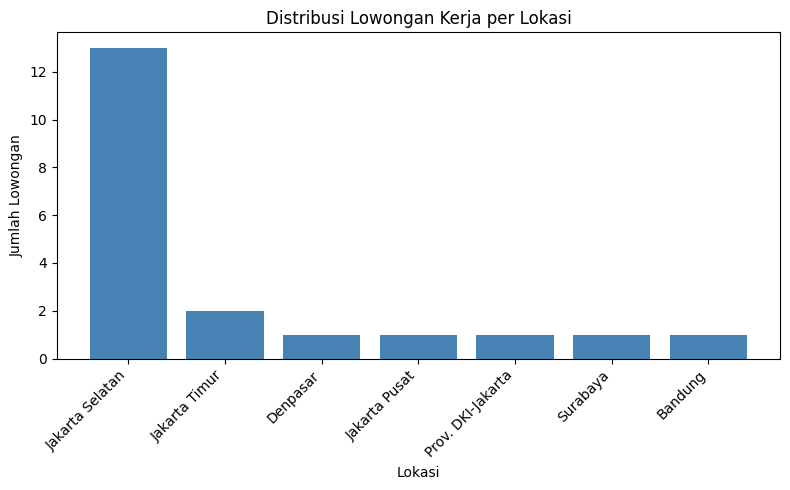

In [19]:
# Distribusi lowongan per lokasi
plt.figure(figsize=(8, 5))
plt.bar(loc_pd["location"], loc_pd["jumlah_lowongan"], color="steelblue")
plt.title("Distribusi Lowongan Kerja per Lokasi")
plt.xlabel("Lokasi")
plt.ylabel("Jumlah Lowongan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_distribusi_lokasi.png")
plt.show()

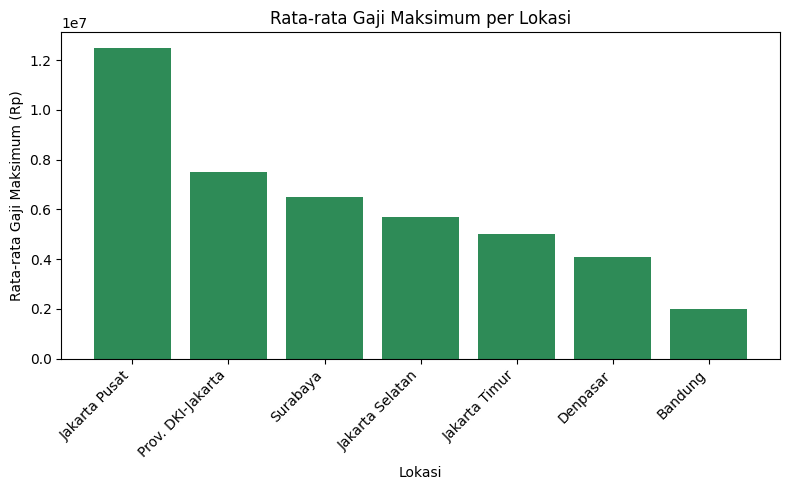

In [20]:
# Rata-rata gaji maksimum per lokasi
plt.figure(figsize=(8, 5))
plt.bar(salary_pd["location"], salary_pd["avg_salary_max"], color="seagreen")
plt.title("Rata-rata Gaji Maksimum per Lokasi")
plt.xlabel("Lokasi")
plt.ylabel("Rata-rata Gaji Maksimum (Rp)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_rata_rata_gaji.png")
plt.show()

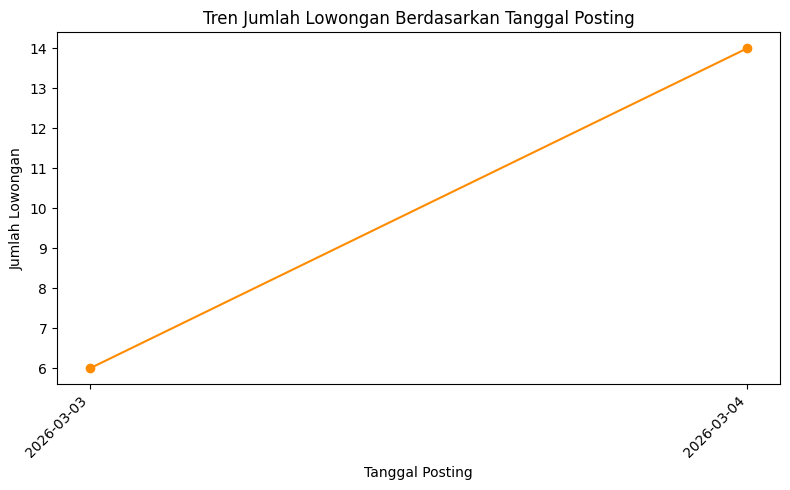

In [21]:
# Tren tanggal posting
plt.figure(figsize=(8, 5))
plt.plot(trend_pd["tanggal_posting"].astype(str), trend_pd["jumlah_lowongan"],
         marker="o", color="darkorange")
plt.title("Tren Jumlah Lowongan Berdasarkan Tanggal Posting")
plt.xlabel("Tanggal Posting")
plt.ylabel("Jumlah Lowongan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_tren_posting.png")
plt.show()

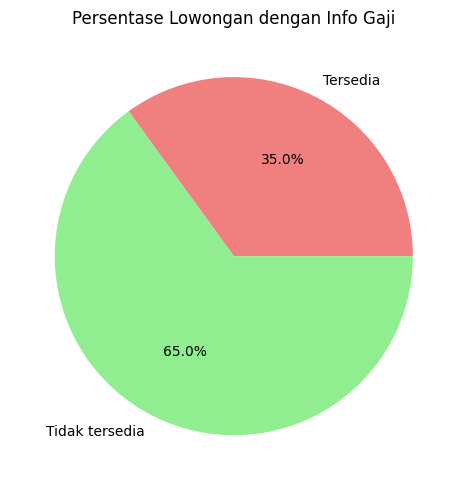

In [22]:
# Persentase lowongan dengan info gaji
plt.figure(figsize=(5, 5))
plt.pie(avail_pd["jumlah"], labels=avail_pd["status_gaji"], autopct="%1.1f%%",
        colors=["lightcoral", "lightgreen"])
plt.title("Persentase Lowongan dengan Info Gaji")
plt.tight_layout()
plt.savefig("chart_ketersediaan_gaji.png")
plt.show()

In [23]:
from google.colab import files as colab_files

colab_files.download("jobs_clean_1.csv")
colab_files.download("chart_distribusi_lokasi.png")
colab_files.download("chart_rata_rata_gaji.png")
colab_files.download("chart_tren_posting.png")
colab_files.download("chart_ketersediaan_gaji.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>